# Hidden Pairs: обучение, оценка и сохранение моделей

## Настройка

In [5]:
# %pip install cleanlab lightgbm catboost

DOWNLOAD_DATA = False
if DOWNLOAD_DATA:
    import kagglehub

    # Download latest version
    path = kagglehub.competition_download('week-03-hidden-pairs')
    print("Path to competition files:", path)

In [6]:
import pandas as pd
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
import time
import cleanlab
import json
from datetime import datetime

import joblib

In [7]:
def set_seed(seed=42):
    """Фиксирует seed для random, NumPy и PyTorch, включая CUDA."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f'Seed: {seed}')

In [8]:
SEED = 42
set_seed(SEED)

LOCAL = not Path('/kaggle/input').exists()

LOG_DIR = Path('./logs') if LOCAL else Path('/kaggle/working/logs')

OUTPUT_DIR = Path('.') if LOCAL else Path('/kaggle/working')
RUN_SEARCH = False
RUN_CLEANLAB = False

Seed: 42


## Данные
Используются исходные признаки без агрегатов. Состав и порядок признаков при предсказании должны совпадать с обучением.

In [9]:
DATA_DIR = Path(path) if DOWNLOAD_DATA else (
    Path('./data') if LOCAL else Path('/kaggle/input/competitions/week-03-hidden-pairs')
)

train_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'train.csv')
val_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'validation.csv')
test_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission: pd.DataFrame = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

train: (2520, 514)
val: (560, 514)
test: (1116, 513)
sample submission: (1116, 2)


In [10]:
assert train_df.isna().sum().sum() == 0, "train_df contains NaN values"
assert val_df.isna().sum().sum() == 0, "val_df contains NaN values"
assert test_df.isna().sum().sum() == 0, "test_df contains NaN values"

assert train_df['row_id'].is_unique, "train_df contains duplicate ids"
assert val_df['row_id'].is_unique, "val_df contains duplicate ids"
assert test_df['row_id'].is_unique, "test_df contains duplicate ids"

In [11]:
feature_columns: list[str] = [
    col for col in train_df.columns if col not in ['row_id', 'target']
]

X_train: pd.DataFrame = train_df[feature_columns]
y_train: pd.Series = train_df['target']

X_val: pd.DataFrame = val_df[feature_columns]
y_val: pd.Series = val_df['target']

X_test: pd.DataFrame = test_df[feature_columns]

print('# of features:', len(feature_columns))
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)
print('X_test shape:', X_test.shape)

# of features: 512
X_train shape: (2520, 512)
y_train shape: (2520,)
X_val shape: (560, 512)
y_val shape: (560,)
X_test shape: (1116, 512)


## Feature Engineering

In [44]:
def aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет признаки каждой строки статистиками, сохраняя индекс.

    row_id и target исключаются. total — сумма значений признаков.
    Пропуски игнорируются; std и var используют ddof=1.
    """
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    mean = vals.mean(axis=1)
    total = vals.sum(axis=1, min_count=1)

    return pd.DataFrame({
        'total': vals.sum(axis=1, min_count=1),
        'count_zeros': vals.eq(0).sum(axis=1),
        'relative_std': vals.std(axis=1) / mean.replace(0, np.nan),
        'max_share': vals.max(axis=1) / total.replace(0, np.nan),
        'q90_median_ratio': (
            vals.quantile(0.9, axis=1)
            / vals.median(axis=1).replace(0, np.nan)
        ),
    }, index=df.index)  

def add_aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет статистики к исходным признакам, исключая row_id и target."""
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    aggregated = aggregate_features(vals)
    return pd.concat([vals, aggregated], axis=1)

X_train_extended = add_aggregate_features(X_train)
X_val_extended = add_aggregate_features(X_val)
X_test_extended = add_aggregate_features(X_test)
X_train_extended.describe()

,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,f0009,...,f0507,f0508,f0509,f0510,f0511,total,count_zeros,relative_std,max_share,q90_median_ratio
count,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,...,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,0.816421,0.351254,0.410664,0.298792,0.316071,0.829884,0.794327,0.458188,0.534329,0.508600,...,0.910349,0.311443,0.888112,0.891143,0.305156,268.232170,3.331746,1.066966,0.014720,3.610789
std,0.770276,0.422683,0.475670,0.359389,0.351609,0.735614,0.750005,0.451543,0.604170,0.657583,...,0.899051,0.377238,0.876417,0.794348,0.397978,109.880246,6.356445,0.092933,0.003388,0.496284
min,0.000914,0.000000,0.000000,0.000000,0.000000,0.000149,0.000000,0.000000,0.000000,0.000000,...,0.000056,0.000000,0.000146,0.000000,0.000000,2.410557,0.000000,0.859895,0.008546,2.565496
25%,0.239064,0.068512,0.079445,0.052415,0.071937,0.247338,0.216560,0.124768,0.106904,0.092206,...,0.237672,0.059558,0.234601,0.250578,0.039672,199.039426,0.000000,1.002270,0.012336,3.284903
50%,0.602737,0.199890,0.248798,0.165667,0.197700,0.640002,0.565030,0.307380,0.311761,0.293996,...,0.623144,0.172119,0.594802,0.670949,0.147515,284.264447,1.000000,1.052929,0.014039,3.530900
75%,1.174830,0.475074,0.572900,0.406414,0.433032,1.208235,1.182003,0.646455,0.737243,0.668198,...,1.316626,0.417279,1.310771,1.331623,0.414805,347.416977,4.000000,1.116399,0.016403,3.818775
max,6.267015,4.428607,3.397339,2.956596,2.682375,4.615446,4.787846,3.038905,4.532887,7.980471,...,7.185578,3.883324,7.317643,4.826770,3.046054,538.929661,65.000000,1.507172,0.039221,7.035003


## Сохранение, загрузка и submission

In [15]:
def save_model(model, model_path):
    """Сохраняет обученную модель; возвращает путь к файлу."""
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_path, compress=3)
    print(f'Обученная модель сохранена: {model_path}', flush=True)
    return model_path


def load_model(json_path, model_name):
    """Загружает модель по JSON запуска и точному имени из поля Model."""
    json_path = Path(json_path)
    run_log = json.loads(json_path.read_text(encoding='utf-8'))
    matches = [row for row in run_log['results'] if row['Model'] == model_name]
    if len(matches) != 1:
        available = [row['Model'] for row in run_log['results']]
        raise ValueError(f'Нужна ровно одна модель {model_name!r}. Доступны: {available}')
    model_path = json_path.parent / matches[0]['Model File']
    print(f'Загружаю {model_name}: {model_path}', flush=True)
    return joblib.load(model_path)


def save_submission(selected_model, X_test, test_ids, sample_submission, output_path):
    """Предсказывает без fit, сохраняет CSV в порядке sample_submission и возвращает его."""
    test_ids = pd.Series(test_ids).reset_index(drop=True)
    if len(X_test) != len(test_ids) or not test_ids.is_unique:
        raise ValueError('Нужен один уникальный row_id на каждую строку X_test')
    if not sample_submission['row_id'].is_unique:
        raise ValueError('В sample_submission есть повторяющиеся row_id')
    if set(test_ids) != set(sample_submission['row_id']):
        raise ValueError('Наборы row_id в test и sample_submission различаются')
    expected = getattr(selected_model, 'feature_names_in_', None)
    if expected is not None and list(X_test.columns) != list(expected):
        raise ValueError('Состав или порядок признаков X_test отличается от обучения')
    # Только предсказания: повторное обучение не запускается.
    print(f'Предсказываю для {len(X_test)} строк...', flush=True)
    test_probs = selected_model.predict_proba(X_test)[:, 1]
    if not np.isfinite(test_probs).all() or not ((test_probs >= 0) & (test_probs <= 1)).all():
        raise ValueError('Модель вернула некорректные вероятности')
    submission = sample_submission[['row_id']].merge(
        pd.DataFrame({'row_id': test_ids, 'target': test_probs}),
        on='row_id', how='left', sort=False, validate='one_to_one',
    )
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(output_path, index=False)
    print(f'Сохранено: {output_path.resolve()} | {submission.shape}', flush=True)
    return submission

In [16]:
def _save_trained_model(model, log_path, model_index, use_cleanlab):
    """Сохраняет обученный классификатор и возвращает путь относительно LOG_DIR.

    После joblib.load() модель готова к predict_proba() без повторного обучения.
    Для CleanLearning сохраняется его финальный обученный классификатор.
    """
    model_dir = log_path.with_suffix('')
    model_dir.mkdir(parents=True, exist_ok=True)
    variant = 'cleanlab' if use_cleanlab else 'base'
    model_path = model_dir / f'{model_index:02d}_{variant}.joblib'
    save_model(model, model_path)
    return str(model_path.relative_to(log_path.parent))

def _save_pipeline_log(log_path, started_at, metrics_list):
    """Сохраняет время запуска, параметры и метрики уже обученных моделей в JSON."""
    log_data = {
        'run_started_at': started_at.isoformat(),
        'updated_at': datetime.now().astimezone().isoformat(),
        'results': json.loads(pd.DataFrame(metrics_list).to_json(orient='records', double_precision=15)),
    }
    log_path.write_text(json.dumps(log_data, ensure_ascii=False, indent=2), encoding='utf-8')

def _record_result(result, run_name, cleanlab_enabled, log_path, model_index,
                   val_predictions, histories, metrics_list, extra_metrics=None):
    """Сохраняет модель и добавляет единообразную строку метрик."""
    model_file = _save_trained_model(result['model'], log_path, model_index, cleanlab_enabled)
    val_predictions[run_name] = result['val_probs']
    histories[run_name] = {
        'train_history': result['train_history'], 'val_history': result['val_history'],
    }
    metrics_list.append({
        'Model': run_name, 'Started At': result['started_at'],
        'Params': result['params'], 'Model File': model_file,
        'Cleanlab': cleanlab_enabled,
        **(extra_metrics or {}),
        'Train AUC': result['train_auc'], 'Val AUC': result['val_auc'],
        'Fit Time (s)': round(result['fit_time'], 3),
    })

## Обучение и графики

In [17]:
def _extract_auc_history(model, X_train, y_train, X_val, y_val):
    """Возвращает списки train/val ROC AUC по итерациям бустинга.

    Для дерева и случайного леса возвращает два пустых списка.
    """
    if isinstance(model, LGBMClassifier):
        history = model.evals_result_
        return history['train']['auc'], history['val']['auc']

    if isinstance(model, GradientBoostingClassifier):
        train_scores = [
            roc_auc_score(y_train, probs[:, 1])
            for probs in model.staged_predict_proba(X_train)
        ]
        val_scores = [
            roc_auc_score(y_val, probs[:, 1])
            for probs in model.staged_predict_proba(X_val)
        ]
        return train_scores, val_scores

    return [], []

def _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=False):
    """Обучает копию модели и возвращает вероятности, AUC, время fit и кривые.

    Validation используется для оценки;
    use_cleanlab=True включает поиск ошибок разметки и обучение через CleanLearning.
    Train AUC считается на исходном train. Время fit включает работу CleanLearning,
    но не включает предсказания и вычисление истории AUC.
    """
    started_at = datetime.now().astimezone().isoformat()
    fitted_model = clone(model)
    print('  Обучение...', flush=True)
    start_time = time.perf_counter()

    fit_kwargs = {}
    if isinstance(fitted_model, LGBMClassifier):
        fit_kwargs = {
            'eval_set': [(X_train, y_train), (X_val, y_val)],
            'eval_names': ['train', 'val'],
            'eval_metric': 'auc',
        }

    if use_cleanlab:
        print('  CleanLearning: ищу ошибки разметки на train и обучаю модель...', flush=True)
        clean_model = cleanlab.classification.CleanLearning(
            clf=fitted_model, seed=SEED, verbose=True,
            find_label_issues_kwargs={'n_jobs': 1},
        )
        # Validation передаётся только финальному fit, не внутренним CV-моделям.
        clean_model.fit(X_train, y_train, clf_final_kwargs=fit_kwargs)
        fitted_model = clean_model.clf
        n_issues = int(clean_model.get_label_issues()['is_label_issue'].sum())
        print(f'  CleanLearning: исключено {n_issues} из {len(y_train)} строк.', flush=True)
    else:
        fitted_model.fit(X_train, y_train, **fit_kwargs)

    fit_time = time.perf_counter() - start_time
    print(f'  Fit завершён за {fit_time:.1f} с. Считаю предсказания и AUC...', flush=True)
    train_probs = fitted_model.predict_proba(X_train)[:, 1]
    val_probs = fitted_model.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    print(f'  Train AUC: {train_auc:.5f} | Val AUC: {val_auc:.5f}', flush=True)
    print('  Извлекаю историю AUC по итерациям...', flush=True)
    train_history, val_history = _extract_auc_history(
        fitted_model, X_train, y_train, X_val, y_val,
    )

    print('  Модель готова.', flush=True)
    return {
        'model': fitted_model,
        'started_at': started_at,
        'params': fitted_model.get_params(deep=False),
        'val_probs': val_probs,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'fit_time': fit_time,
        'train_history': train_history,
        'val_history': val_history,
    }

In [18]:
def _plot_learning_curves(histories, ncols=2):
    """Рисует train/val ROC AUC по итерациям для моделей с историей обучения."""
    histories = {name: result for name, result in histories.items() if result['val_history']}
    if not histories:
        return

    sns.set_theme(style='darkgrid')
    nrows = (len(histories) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False,
    )
    axes = axes.ravel()

    for ax, (name, result) in zip(axes, histories.items()):
        for key, label in [('train_history', 'Train AUC'), ('val_history', 'Val AUC')]:
            scores = result[key]
            ax.plot(range(1, len(scores) + 1), scores, label=label)
        ax.set(title=name, xlabel='Iteration', ylabel='ROC AUC')
        ax.legend()

    # Удаление неиспользуемых ячеек сетки (если количество моделей нечетное)
    for ax in axes[len(histories):]:
        fig.delaxes(ax)

    fig.tight_layout()
    plt.show()

In [19]:
def run_model_pipeline(
    models_dict, X_train, y_train, X_val, y_val, plot_curves=True, use_cleanlab=False,
):
    """Обучает модели и возвращает вероятности на val и таблицу AUC/времени.

    Строки вероятностей соответствуют X_val; метрики отсортированы по Val AUC.
    use_cleanlab=True запускает каждую модель дважды: без очистки, затем с ней.
    Версия с очисткой получает суффикс " + Cleanlab" в таблицах и графиках.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"pipeline_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Пайплайн: {len(models_dict)} моделей | train={X_train.shape}, val={X_val.shape}', flush=True)
    for i, (name, model) in enumerate(models_dict.items(), start=1):
        print(f'\n[{i}/{len(models_dict)}] {name}', flush=True)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)
            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

In [20]:
def run_model_pipeline_search(
    models_dict, param_grids, X_train, y_train, X_val, y_val,
    n_iter=10, cv=5, scoring='roc_auc', verbose=10, n_jobs=-1, plot_curves=True,
    use_cleanlab=False,
):
    """Подбирает параметры на train для моделей, перечисленных в param_grids.

    Параметры подбираются один раз без CleanLearning. При use_cleanlab=True
    лучшая конфигурация обучается без очистки, затем с ней. CV Score/STD в обеих
    строках относятся к одному поиску без очистки.
    Возвращает вероятности и метрики: CV Score/STD относятся к scoring,
    Train/Val AUC — к финальной модели, Fit Time — к её обучению без поиска.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"search_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Поиск: {len(param_grids)} моделей | метрика={scoring}', flush=True)
    if use_cleanlab:
        print('CleanLearning включён после поиска. CV Score — без очистки.', flush=True)
    for i, (name, param_grid) in enumerate(param_grids.items(), start=1):
        print(f'\n[{i}/{len(param_grids)}] {name}: подбор параметров...', flush=True)
        if not param_grid:
            raise ValueError(f'Пустая сетка параметров: {name}')
        model = clone(models_dict[name])
        if 'n_jobs' in model.get_params():
            model.set_params(n_jobs=1)
        search = RandomizedSearchCV(
            model, param_distributions=param_grid, n_iter=n_iter,
            cv=cv, scoring=scoring, random_state=SEED,
            verbose=verbose, n_jobs=n_jobs, refit=False, pre_dispatch='n_jobs',
        )
        search_start = time.perf_counter()
        with joblib.parallel_config(backend='loky', inner_max_num_threads=1):
            search.fit(X_train, y_train)
        print(
            f'  Поиск завершён за {time.perf_counter() - search_start:.1f} с. '
            f'Лучший CV {scoring}: {search.best_score_:.5f}',
            flush=True,
        )
        print(f'  Параметры: {search.best_params_}', flush=True)
        print('  Обучаю лучшую конфигурацию на всём train.', flush=True)
        best_model = clone(model).set_params(**search.best_params_)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(best_model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)

            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
                extra_metrics={
                    'Best Params': search.best_params_,
                    'CV Score': search.best_score_,
                    'CV STD': search.cv_results_['std_test_score'][search.best_index_],
                },
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

## Сравнение моделей

In [54]:
lightgbm_params = {
  "subsample": 0.6,
  "reg_lambda": 0.0,
  "reg_alpha": 0.0,
  "num_leaves": 16,
  "n_estimators": 2000,
  "min_child_samples": 20,
  "max_depth": 6,
  "learning_rate": 0.05,
  "colsample_bytree": 0.5
}

gbmt_params = {
  "subsample": 0.6,
  "n_estimators": 2000,
  "min_samples_split": 5,
  "min_samples_leaf": 30,
  "max_features": 0.1,
  "max_depth": 4,
  "learning_rate": 0.1
}

random_forest_params = {
  "n_estimators": 2000,
  "min_samples_split": 10,
  "min_samples_leaf": 5,
  "max_features": 0.5,
  "max_depth": 10
}

In [55]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        **random_forest_params,
        random_state=SEED,
        n_jobs=-1,
    ),
    'GBDT': GradientBoostingClassifier(
       **gbmt_params,
       random_state=SEED,
    ),
    'LightGBM': LGBMClassifier(
        **lightgbm_params,
        random_state=SEED,
        n_jobs=1,
        verbose=-1,
    ),
}

Лог запуска: /Users/platon/Documents/sbmt_kaggle/logs/pipeline_2026-09-20_11-44-35_050259.json
Пайплайн: 1 моделей | train=(2520, 512), val=(560, 512)

[1/1] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 20.4 с. Считаю предсказания и AUC...
  Train AUC: 1.00000 | Val AUC: 0.92379
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_11-44-35_050259/01_base.joblib
  Результат сохранён: pipeline_2026-09-20_11-44-35_050259.json

Строю графики AUC...


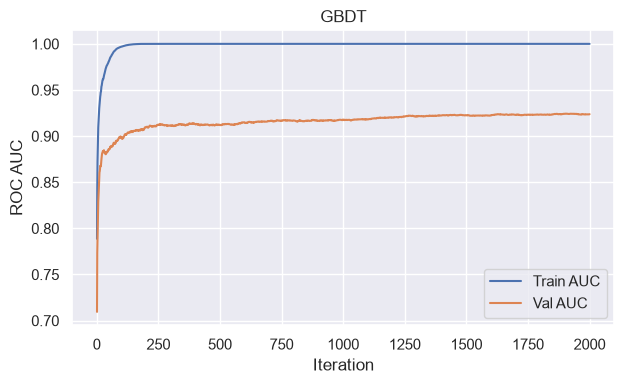

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [56]:
preds_df, metrics_df = run_model_pipeline(
    {'GBDT': models['GBDT']}, X_train, y_train, X_val, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [41]:
metrics_df

,Model,Started At,Params,Model File,Cleanlab,Train AUC,Val AUC,Fit Time (s)
0,GBDT,2026-09-20T10:12:01.137118+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-20_10-11-10_497382/03_base.jo...,False,1.000000,0.924860,53.886
1,LightGBM,2026-09-20T10:13:02.507350+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-20_10-11-10_497382/04_base.jo...,False,1.000000,0.924745,13.723
2,Random Forest,2026-09-20T10:11:11.002624+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-20_10-11-10_497382/02_base.jo...,False,0.999102,0.908469,49.115
3,Decision Tree,2026-09-20T10:11:10.499245+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-20_10-11-10_497382/01_base.jo...,False,0.893775,0.855357,0.484


Лог запуска: /Users/platon/Documents/sbmt_kaggle/logs/pipeline_2026-09-20_10-15-26_714585.json
Пайплайн: 4 моделей | train=(2520, 517), val=(560, 517)

[1/4] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 0.5 с. Считаю предсказания и AUC...
  Train AUC: 0.89377 | Val AUC: 0.85536
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_10-15-26_714585/01_base.joblib
  Результат сохранён: pipeline_2026-09-20_10-15-26_714585.json

[2/4] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 48.3 с. Считаю предсказания и AUC...
  Train AUC: 0.99905 | Val AUC: 0.90821
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_10-15-26_714585/02_base.joblib
  Результат сохранён: pipeline_2026-09-20_10-15-26_714585.json

[3/4] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 53.3 с. Считаю предсказания и AUC...
  Train AUC: 1.00000 | Val AUC: 0.925

/Users/platon/Documents/sbmt_kaggle/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  Fit завершён за 14.3 с. Считаю предсказания и AUC...
  Train AUC: 1.00000 | Val AUC: 0.92468
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_10-15-26_714585/04_base.joblib
  Результат сохранён: pipeline_2026-09-20_10-15-26_714585.json

Строю графики AUC...


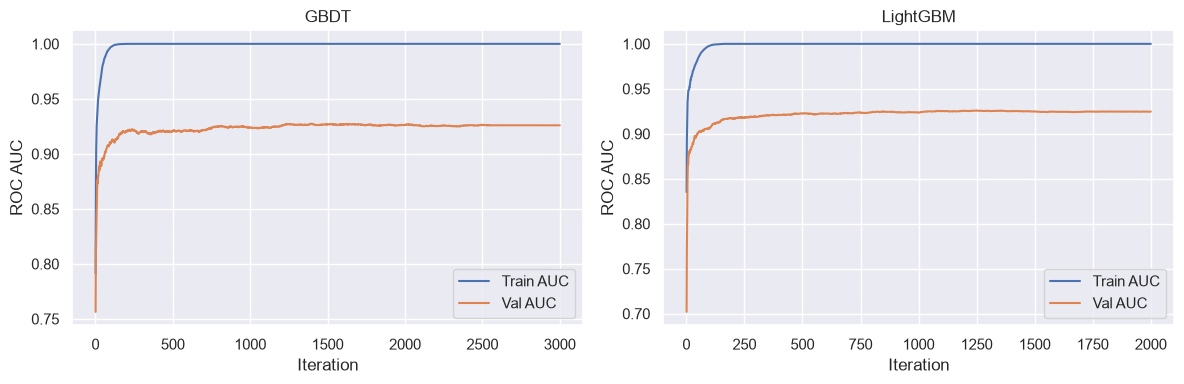

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [45]:
preds_df_extended, metrics_df_extended = run_model_pipeline(
    models, X_train_extended, y_train, X_val_extended, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [46]:
metrics_df_extended

,Model,Started At,Params,Model File,Cleanlab,Train AUC,Val AUC,Fit Time (s)
0,GBDT,2026-09-20T10:16:16.584081+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-20_10-15-26_714585/03_base.jo...,False,1.000000,0.925969,53.308
1,LightGBM,2026-09-20T10:17:17.693091+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-20_10-15-26_714585/04_base.jo...,False,1.000000,0.924681,14.296
2,Random Forest,2026-09-20T10:15:27.238495+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-20_10-15-26_714585/02_base.jo...,False,0.999048,0.908214,48.295
3,Decision Tree,2026-09-20T10:15:26.717281+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-20_10-15-26_714585/01_base.jo...,False,0.893775,0.855357,0.503


## Эксперимент: log1p → StandardScaler → RBF SVC

Используем `X_train_extended`, `X_val_extended`, `X_test_extended` из Feature Engineering. SVC — самостоятельная модель, GBDT здесь не участвует.

CV ROC-AUC считаем по `decision_function`. Все преобразования обучаются внутри фолдов. Затем калибруем вероятности на train для `predict_proba` и submission; validation в обучении и калибровке не участвует. Сохраняем весь конвейер, поэтому при загрузке передаём extended-признаки **без ручного log1p и масштабирования**.

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

svc_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
    ('svc', SVC(C=10, kernel='rbf', gamma='scale')),
])
svc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, features in [('train', X_train_extended), ('val', X_val_extended),
                       ('test', X_test_extended)]:
    if not np.isfinite(features.to_numpy()).all() or (features < 0).any().any():
        raise ValueError(f'{name}: для этого эксперимента нужны конечные неотрицательные признаки')
    if list(features.columns) != list(X_train_extended.columns):
        raise ValueError(f'{name}: состав или порядок признаков отличается от train')
print(f'SVC: {X_train_extended.shape[1]} признаков')

SVC: 517 признаков


In [59]:
svc_cv_scores = cross_val_score(
    svc_pipeline, X_train_extended, y_train,
    cv=svc_cv, scoring='roc_auc', n_jobs=1,
)
print('CV AUC по фолдам:', np.round(svc_cv_scores, 5))
print(f'CV AUC: {svc_cv_scores.mean():.5f} ± {svc_cv_scores.std():.5f}')

CV AUC по фолдам: [0.93662 0.92782 0.92761 0.92503 0.92536]
CV AUC: 0.92849 ± 0.00422


In [60]:
# Калибруется весь Pipeline: scaler обучается заново внутри каждого фолда.
# ensemble=False: итоговая SVC обучается на всём train.
svc_model = CalibratedClassifierCV(
    estimator=svc_pipeline, method='sigmoid', cv=svc_cv, ensemble=False,
)
svc_started_at = datetime.now().astimezone()
svc_start = time.perf_counter()
svc_model.fit(X_train_extended, y_train)
svc_fit_time = time.perf_counter() - svc_start

svc_train_probs = svc_model.predict_proba(X_train_extended)[:, 1]
svc_val_probs = svc_model.predict_proba(X_val_extended)[:, 1]
svc_metrics = pd.DataFrame([{
    'Model': 'log1p + StandardScaler + RBF SVC (extended)',
    'CV AUC (decision_function)': svc_cv_scores.mean(),
    'CV STD': svc_cv_scores.std(),
    'Train AUC': roc_auc_score(y_train, svc_train_probs),
    'Val AUC': roc_auc_score(y_val, svc_val_probs),
    'Fit + Calibration Time (s)': round(svc_fit_time, 3),
}])

svc_run_dir = LOG_DIR / f'svc_{svc_started_at:%Y-%m-%d_%H-%M-%S_%f}'
svc_model_path = save_model(svc_model, svc_run_dir / 'model.joblib')
svc_log = {
    'run_started_at': svc_started_at.isoformat(),
    'feature_columns': list(X_train_extended.columns),
    'params': {'C': 10, 'kernel': 'rbf', 'gamma': 'scale'},
    'preprocessing': ['log1p', 'StandardScaler'],
    'calibration': {'method': 'sigmoid', 'ensemble': False, 'folds': 5},
    'seed': SEED,
    'cv_scores': svc_cv_scores.tolist(),
    'results': [{
        **json.loads(svc_metrics.to_json(orient='records'))[0],
        'Model File': 'model.joblib',
    }],
}
(svc_run_dir / 'results.json').write_text(
    json.dumps(svc_log, ensure_ascii=False, indent=2), encoding='utf-8',
)
pd.DataFrame({
    'row_id': val_df['row_id'], 'target': y_val, 'prediction': svc_val_probs,
}).to_csv(svc_run_dir / 'validation_predictions.csv', index=False)
print(f'Результаты: {svc_run_dir.resolve()}')
display(svc_metrics)

Обученная модель сохранена: logs/svc_2026-09-20_11-48-16_709845/model.joblib
Результаты: /Users/platon/Documents/sbmt_kaggle/logs/svc_2026-09-20_11-48-16_709845


,Model,CV AUC (decision_function),CV STD,Train AUC,Val AUC,Fit + Calibration Time (s)
0,log1p + StandardScaler + RBF SVC (extended),0.928486,0.004221,1.0,0.946888,2.18


In [ ]:
# Выполни эти строки, когда понадобится файл для Kaggle:
# submission_svc = save_submission(
#     svc_model, X_test_extended, test_df['row_id'], sample_submission,
#     OUTPUT_DIR / 'submission_svc_extended.csv',
# )

# После перезапуска ядра можно загрузить весь обученный конвейер:
# svc_model = load_model(svc_run_dir / 'results.json', svc_log['results'][0]['Model'])

Предсказываю для 1116 строк...
Сохранено: /Users/platon/Documents/sbmt_kaggle/submission_svc_extended.csv | (1116, 2)


## Поиск параметров
Включается флагом `RUN_SEARCH` в настройках.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.5],
    },
}

In [ ]:
preds_df_search = metrics_df_search = None
if RUN_SEARCH:
    preds_df_search, metrics_df_search = run_model_pipeline_search(
        models, param_grids, X_train, y_train, X_val, y_val,
        n_iter=30, cv=cv, scoring='roc_auc', plot_curves=True,
        verbose=10, n_jobs=-1,
    )
    display(metrics_df_search)

## Эксперименты с CleanLearning
Включаются флагом `RUN_CLEANLAB` в настройках.

In [ ]:
if RUN_CLEANLAB:
    model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
    cl = cleanlab.classification.CleanLearning(model, seed=SEED, verbose=True)
    cl.fit(X_train, y_train)
    model = clone(model)
    model.fit(X_train, y_train)

    # issues = cl.get_label_issues()
    # print(issues['is_label_issue'].sum())
    print("Val AUC (cleaned):", roc_auc_score(y_val, cl.predict_proba(X_val)[:, 1]))
    print('Val AUC (model):', roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    print('model params:', model.get_params())

In [ ]:
# True — сравнить обычную модель и CleanLearning.
if RUN_CLEANLAB:
    models_clean = {'LightGBM': models['LightGBM']}
    preds_df_clean, metrics_df_clean = run_model_pipeline(
        models_clean, X_train, y_train, X_val, y_val, use_cleanlab=True,
    )
    display(metrics_df_clean)

## Предсказания сохранённой модели
Для предсказаний достаточно выполнить настройку, подготовку данных и функции сохранения/загрузки. Обучение запускать не нужно. Укажи JSON_PATH ниже.

In [35]:
# Укажи JSON запуска и точное имя модели из поля Model.
# Нужны JSON и папка с .joblib рядом с ним.
JSON_PATH = LOG_DIR / 'pipeline_2026-09-20_09-54-32_326015.json'  # Например: LOG_DIR / 'pipeline_2026-09-19_20-51-16_279271.json'
MODEL_NAME = 'GBDT'  # Например: 'Random Forest + Cleanlab'
SUBMISSION_PATH = OUTPUT_DIR / 'submission_GBDT_extended.csv'

if JSON_PATH is not None:
    selected_model = load_model(JSON_PATH, MODEL_NAME)
    submission = save_submission(
        selected_model, X_test_extended, test_df['row_id'], sample_submission, SUBMISSION_PATH,
    )
    display(submission.head())

Загружаю GBDT: logs/pipeline_2026-09-20_09-54-32_326015/03_base.joblib
Предсказываю для 1116 строк...
Сохранено: /Users/platon/Documents/sbmt_kaggle/submission_GBDT_extended.csv | (1116, 2)


,row_id,target
0,row_46ad1afad8562239f79c,1.000000
1,row_b42ade9cd57b8d919acb,0.999994
2,row_c951cd5e197b6b4e8b83,0.007596
3,row_a54b3423760d599416ce,0.000002
4,row_a87c87cc47690e2a303f,1.000000
